In [ ]:
# =====================================================
# CELL 1: INSTALL DEPENDENCIES
# Run once per fresh Colab session
# =====================================================
!pip install -q pandas numpy nltk transformers sentencepiece accelerate tqdm rouge-score scikit-learn

  Preparing metadata (setup.py) ... done


In [ ]:
# =====================================================
# CELL 2: IMPORTS + DRIVE
# =====================================================
import os
import re
import gc
import json
import time
import numpy as np
import pandas as pd
import nltk
import torch

from tqdm import tqdm
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

from google.colab import drive
drive.mount('/content/drive')

nltk.download("punkt")
nltk.download("punkt_tab")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# CELL 3: PATHS + CONFIG
# =====================================================
TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/yelp_bart_abstractive_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
VAL_SIZE = 0.1

MODEL_NAME = "facebook/bart-large-cnn"

# Keep same as IMDb BART
MAX_INPUT_LENGTH = 1024
MAX_SUMMARY_LENGTH = 80
MIN_SUMMARY_LENGTH = 20
NUM_BEAMS = 2
LENGTH_PENALTY = 2.0
EARLY_STOPPING = True

# Best practical setup
BATCH_SIZE = 32 if torch.cuda.is_available() else 1
CHECKPOINT_EVERY = 100
EVAL_SAMPLE_SIZE = 2000

RUN_NAME = "yelp_bart_abstractive"

print("Output folder:", OUTPUT_DIR)
print("Model name   :", MODEL_NAME)
print("Batch size   :", BATCH_SIZE)
print("Checkpoint every:", CHECKPOINT_EVERY, "batches")

Output folder: /content/drive/MyDrive/yelp_bart_abstractive_outputs
Model name   : facebook/bart-large-cnn
Batch size   : 32
Checkpoint every: 100 batches


In [ ]:
# =====================================================
# CELL 4: LOAD DATASET
# =====================================================
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("train.csv:", train_df.shape)
print("test.csv :", test_df.shape)

label_map = {1: 0, 2: 1}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

Original shapes:
train.csv: (560000, 2)
test.csv : (38000, 2)


In [ ]:
# =====================================================
# CELL 5: CLEAN TEXT
# =====================================================
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.replace("<br />", " ")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df = train_df.dropna(subset=["text", "label"]).drop_duplicates().reset_index(drop=True)
test_df = test_df.dropna(subset=["text", "label"]).drop_duplicates().reset_index(drop=True)

train_df["text"] = train_df["text"].astype(str).apply(clean_text)
test_df["text"] = test_df["text"].astype(str).apply(clean_text)

train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nLabel distribution:")
print("Train:\n", train_df["label"].value_counts().sort_index())
print("Test:\n", test_df["label"].value_counts().sort_index())


After cleaning:
Train shape: (559994, 2)
Test shape : (38000, 2)

Label distribution:
Train:
 label
0    279997
1    279997
Name: count, dtype: int64
Test:
 label
0    19000
1    19000
Name: count, dtype: int64


In [ ]:
# =====================================================
# CELL 6: TRAIN / VALIDATION / TEST SPLIT
# =====================================================
train_split_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", len(train_split_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nLabel distributions:")
print("Train:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Val:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

train_split_df.to_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_train_split_used.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_val_split_used.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_test_split_used.csv"), index=False)


Split sizes:
Train: 503994
Val  : 56000
Test : 38000

Label distributions:
Train:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Val:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
# =====================================================
# CELL 7: PREPARE TEXT/LABEL LISTS
# =====================================================
train_texts = train_split_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_split_df["label"].tolist()
val_labels = val_df["label"].tolist()
test_labels = test_df["label"].tolist()

print("Prepared:")
print("Train:", len(train_texts))
print("Val  :", len(val_texts))
print("Test :", len(test_texts))

Prepared:
Train: 503994
Val  : 56000
Test : 38000


In [ ]:
# =====================================================
# CELL 8: LOAD BART MODEL
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print("Running on:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Running on: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# CELL 9: HELPER FUNCTIONS
# Append-only saving + JSON checkpoint
# =====================================================
def get_output_csv_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}.csv")

def get_checkpoint_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}_checkpoint.json")

def get_time_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}_time.json")

def generate_summary_batch(text_batch):
    inputs = tokenizer(
        [str(t).strip() for t in text_batch],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_INPUT_LENGTH
    ).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=MAX_SUMMARY_LENGTH,
            min_length=MIN_SUMMARY_LENGTH,
            num_beams=NUM_BEAMS,
            length_penalty=LENGTH_PENALTY,
            early_stopping=EARLY_STOPPING
        )

    summaries = tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
    return [s.strip() for s in summaries]

def append_batch_to_csv(split_name, batch_texts, batch_summaries, batch_labels):
    csv_path = get_output_csv_path(split_name)

    batch_df = pd.DataFrame({
        "original_text": batch_texts,
        "summary_text": batch_summaries,
        "label": batch_labels
    })

    file_exists = os.path.exists(csv_path)
    batch_df.to_csv(csv_path, mode="a", header=not file_exists, index=False)

def load_resume_state(split_name):
    csv_path = get_output_csv_path(split_name)
    ckpt_path = get_checkpoint_path(split_name)

    completed = 0

    if os.path.exists(csv_path):
        try:
            existing_df = pd.read_csv(csv_path)
            completed = len(existing_df)
            print(f"Found existing {split_name} CSV with {completed} rows.")
        except Exception as e:
            print(f"Could not read existing CSV for {split_name}: {e}")
            completed = 0

    if os.path.exists(ckpt_path):
        try:
            with open(ckpt_path, "r") as f:
                ckpt = json.load(f)
            completed = max(completed, ckpt.get("rows_saved", 0))
            print(f"Found checkpoint for {split_name}: {ckpt}")
        except Exception as e:
            print(f"Could not read checkpoint for {split_name}: {e}")

    return completed

def save_resume_state(split_name, rows_saved):
    ckpt_path = get_checkpoint_path(split_name)
    with open(ckpt_path, "w") as f:
        json.dump({"rows_saved": int(rows_saved)}, f)

def save_elapsed_time(split_name, elapsed_seconds):
    time_path = get_time_path(split_name)
    with open(time_path, "w") as f:
        json.dump({"elapsed_seconds": float(elapsed_seconds)}, f)

def load_elapsed_time(split_name):
    time_path = get_time_path(split_name)
    if os.path.exists(time_path):
        try:
            with open(time_path, "r") as f:
                return json.load(f).get("elapsed_seconds", 0.0)
        except Exception:
            return 0.0
    return 0.0

def summarise_with_resume_append(texts, labels, split_name, batch_size=BATCH_SIZE):
    completed = load_resume_state(split_name)
    previous_elapsed = load_elapsed_time(split_name)

    if completed >= len(texts):
        print(f"{split_name} already completed.")
        return completed, previous_elapsed

    print(f"Resuming {split_name} from row {completed}")

    start_time = time.time()

    for batch_idx, start in enumerate(
        tqdm(range(completed, len(texts), batch_size), desc=f"Summarising {split_name}"),
        start=1
    ):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]
        batch_labels = labels[start:end]

        try:
            batch_summaries = generate_summary_batch(batch_texts)
        except Exception as e:
            print(f"\nError at batch {start}-{end}: {e}")
            batch_summaries = [""] * len(batch_texts)

        append_batch_to_csv(split_name, batch_texts, batch_summaries, batch_labels)

        rows_saved = end
        if batch_idx % CHECKPOINT_EVERY == 0 or end == len(texts):
            save_resume_state(split_name, rows_saved)
            elapsed_so_far = previous_elapsed + (time.time() - start_time)
            save_elapsed_time(split_name, elapsed_so_far)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    elapsed = previous_elapsed + (time.time() - start_time)
    save_resume_state(split_name, len(texts))
    save_elapsed_time(split_name, elapsed)

    print(f"\nFinished {split_name}")
    print("Rows saved:", len(texts))
    print("Elapsed minutes:", round(elapsed / 60, 2))

    return len(texts), elapsed

In [ ]:
# =====================================================
# CELL 10: RUN TRAIN ONLY
# Run this first
# =====================================================
train_done, train_time = summarise_with_resume_append(train_texts, train_labels, "train")
print("Train rows completed:", train_done)
print("Train time (hours):", round(train_time / 3600, 2))

Resuming train from row 0


Summarising train: 100%|██████████| 15750/15750 [14:34:30<00:00,  3.33s/it]


Finished train
Rows saved: 503994
Elapsed minutes: 874.51
Train rows completed: 503994
Train time (hours): 14.58


In [ ]:
# =====================================================
# CELL 11: RUN VALIDATION ONLY
# Run only after train is finished
# =====================================================
val_done, val_time = summarise_with_resume_append(val_texts, val_labels, "val")
print("Validation rows completed:", val_done)
print("Validation time (hours):", round(val_time / 3600, 2))

Resuming val from row 0


Summarising val: 100%|██████████| 1750/1750 [1:36:26<00:00,  3.31s/it]


Finished val
Rows saved: 56000
Elapsed minutes: 96.44
Validation rows completed: 56000
Validation time (hours): 1.61


In [ ]:
# =====================================================
# CELL 12: RUN TEST ONLY
# Run only after validation is finished
# =====================================================
test_done, test_time = summarise_with_resume_append(test_texts, test_labels, "test")
print("Test rows completed:", test_done)
print("Test time (hours):", round(test_time / 3600, 2))

Resuming test from row 0


Summarising test: 100%|██████████| 1188/1188 [1:04:25<00:00,  3.25s/it]


Finished test
Rows saved: 38000
Elapsed minutes: 64.42
Test rows completed: 38000
Test time (hours): 1.07


In [ ]:
# =====================================================
# CELL 13: CHECK SAVED FILES
# Useful after reconnect
# =====================================================
for split_name in ["train", "val", "test"]:
    csv_path = get_output_csv_path(split_name)
    ckpt_path = get_checkpoint_path(split_name)

    print("\nSPLIT:", split_name)
    print("CSV exists :", os.path.exists(csv_path))
    print("JSON exists:", os.path.exists(ckpt_path))

    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            print("Rows:", len(df))
            display(df.head(2))
        except Exception as e:
            print("CSV read error:", e)


SPLIT: train
CSV exists : True
JSON exists: True
Rows: 503994


,original_text,summary_text,label
0,Always has been good!,Always has been good! always has beenGood! alw...,1
1,I love the cheap drinks. Cheaper than QT even....,I love the cheap drinks. Cheaper than QT even....,0



SPLIT: val
CSV exists : True
JSON exists: True
Rows: 56000


,original_text,summary_text,label
0,"\""Just finished having Daniel's move my daught...",Daniel's Moving & Storage moved my daughter fr...,1
1,"Service is bad, bad, bad. Although the food is...","Service is bad, bad,Bad. Although the food is ...",0



SPLIT: test
CSV exists : True
JSON exists: True
Rows: 38000


,original_text,summary_text,label
0,"Contrary to other reviews, I have zero complai...","Contrary to other reviews, I have zero complai...",1
1,Last summer I had an appointment to get new ti...,Last summer I had an appointment to get new ti...,0


In [ ]:
# =====================================================
# CELL 14: LOAD FINISHED OUTPUTS
# Run after train/val/test are done
# =====================================================
train_summary_df = pd.read_csv(get_output_csv_path("train"))
val_summary_df = pd.read_csv(get_output_csv_path("val"))
test_summary_df = pd.read_csv(get_output_csv_path("test"))

print(train_summary_df.shape, val_summary_df.shape, test_summary_df.shape)

(503994, 3) (56000, 3) (38000, 3)


In [ ]:
# =====================================================
# CELL 15: SHOW SAMPLE OUTPUT
# =====================================================
if len(train_summary_df) > 0:
    print("\n================ SAMPLE ================\n")
    print("Original text:\n")
    print(train_summary_df.iloc[0]["original_text"][:1000])

    print("\nSummary text:\n")
    print(train_summary_df.iloc[0]["summary_text"][:1000])


================ SAMPLE ================

Original text:

Always has been good!

Summary text:

Always has been good! always has beenGood! always will be good! Always has beengood! always good!


In [ ]:
# =====================================================
# CELL 16: EVALUATION FUNCTION
# =====================================================
def evaluate_abstractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method1

    if EVAL_SAMPLE_SIZE is not None and len(original_texts) > EVAL_SAMPLE_SIZE:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(original_texts), size=EVAL_SAMPLE_SIZE, replace=False)
        original_eval = [original_texts[i] for i in idx]
        summary_eval = [summary_texts[i] for i in idx]
    else:
        original_eval = list(original_texts)
        summary_eval = list(summary_texts)

    for original, summary in tqdm(
        zip(original_eval, summary_eval),
        total=len(original_eval),
        desc=f"Evaluating {dataset_name}"
    ):
        original = str(original)
        summary = str(summary)

        orig_words = len(word_tokenize(original))
        summ_words = len(word_tokenize(summary))
        orig_sents = len(sent_tokenize(original))
        summ_sents = len(sent_tokenize(summary))

        original_word_counts.append(orig_words)
        summary_word_counts.append(summ_words)
        original_sentence_counts.append(orig_sents)
        summary_sentence_counts.append(summ_sents)

        reference = " ".join(sent_tokenize(original)[:2])

        try:
            scores = scorer.score(reference, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougeL_scores.append(scores["rougeL"].fmeasure)
        except Exception:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougeL_scores.append(np.nan)

        try:
            bleu_scores.append(
                sentence_bleu([reference.split()], summary.split(), smoothing_function=smoothie)
            )
        except Exception:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)
    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
    sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

    result = {
        "dataset": dataset_name,
        "avg_original_words": round(avg_original_words, 2),
        "avg_summary_words": round(avg_summary_words, 2),
        "avg_original_sentences": round(avg_original_sentences, 2),
        "avg_summary_sentences": round(avg_summary_sentences, 2),
        "word_compression_ratio": round(word_compression_ratio, 4),
        "sentence_compression_ratio": round(sentence_compression_ratio, 4),
        "rouge_1": round(np.nanmean(rouge1_scores), 4),
        "rouge_2": round(np.nanmean(rouge2_scores), 4),
        "rouge_L": round(np.nanmean(rougeL_scores), 4),
        "bleu": round(np.nanmean(bleu_scores), 4),
    }

    print("\n================================")
    print("EVALUATION:", dataset_name)
    print("================================")
    for k, v in result.items():
        if k != "dataset":
            print(f"{k}: {v}")

    return result

In [ ]:
# =====================================================
# CELL 17: RUN EVALUATION
# =====================================================
evaluation_results = []

evaluation_results.append(
    evaluate_abstractive_summaries(
        train_summary_df["original_text"].tolist(),
        train_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_train"
    )
)

evaluation_results.append(
    evaluate_abstractive_summaries(
        val_summary_df["original_text"].tolist(),
        val_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_val"
    )
)

evaluation_results.append(
    evaluate_abstractive_summaries(
        test_summary_df["original_text"].tolist(),
        test_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_test"
    )
)

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_path = os.path.join(OUTPUT_DIR, f"{RUN_NAME}_evaluation.csv")
evaluation_df.to_csv(evaluation_path, index=False)

print("\nSaved evaluation results:")
print(evaluation_path)
display(evaluation_df)

Evaluating yelp_bart_abstractive_train: 100%|██████████| 2000/2000 [00:05<00:00, 383.33it/s]



EVALUATION: yelp_bart_abstractive_train
avg_original_words: 149.56
avg_summary_words: 39.36
avg_original_sentences: 8.44
avg_summary_sentences: 3.02
word_compression_ratio: 0.2632
sentence_compression_ratio: 0.3582
rouge_1: 0.4853
rouge_2: 0.4009
rouge_L: 0.4519
bleu: 0.3104


Evaluating yelp_bart_abstractive_val: 100%|██████████| 2000/2000 [00:05<00:00, 380.85it/s]



EVALUATION: yelp_bart_abstractive_val
avg_original_words: 157.31
avg_summary_words: 39.45
avg_original_sentences: 8.65
avg_summary_sentences: 2.97
word_compression_ratio: 0.2508
sentence_compression_ratio: 0.3431
rouge_1: 0.4943
rouge_2: 0.4113
rouge_L: 0.4615
bleu: 0.319


Evaluating yelp_bart_abstractive_test: 100%|██████████| 2000/2000 [00:05<00:00, 392.21it/s]


EVALUATION: yelp_bart_abstractive_test
avg_original_words: 154.44
avg_summary_words: 38.53
avg_original_sentences: 8.67
avg_summary_sentences: 2.97
word_compression_ratio: 0.2495
sentence_compression_ratio: 0.342
rouge_1: 0.4734
rouge_2: 0.3894
rouge_L: 0.4436
bleu: 0.2994

Saved evaluation results:
/content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_evaluation.csv


,dataset,avg_original_words,avg_summary_words,avg_original_sentences,avg_summary_sentences,word_compression_ratio,sentence_compression_ratio,rouge_1,rouge_2,rouge_L,bleu
0,yelp_bart_abstractive_train,149.56,39.36,8.44,3.02,0.2632,0.3582,0.4853,0.4009,0.4519,0.3104
1,yelp_bart_abstractive_val,157.31,39.45,8.65,2.97,0.2508,0.3431,0.4943,0.4113,0.4615,0.3190
2,yelp_bart_abstractive_test,154.44,38.53,8.67,2.97,0.2495,0.3420,0.4734,0.3894,0.4436,0.2994


In [ ]:
# =====================================================
# CELL 18: GENERATION TIME SUMMARY
# =====================================================
time_records = []

for split_name in ["train", "val", "test"]:
    elapsed = load_elapsed_time(split_name)
    if elapsed > 0:
        time_records.append({
            "split": split_name,
            "generation_time_sec": round(elapsed, 2),
            "generation_time_hr": round(elapsed / 3600, 2)
        })

time_df = pd.DataFrame(time_records)
time_path = os.path.join(OUTPUT_DIR, f"{RUN_NAME}_generation_times.csv")
time_df.to_csv(time_path, index=False)

print("\nSaved generation times:")
print(time_path)
display(time_df)


Saved generation times:
/content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_generation_times.csv


,split,generation_time_sec,generation_time_hr
0,train,52470.67,14.58
1,val,5786.61,1.61
2,test,3865.22,1.07


In [ ]:
# =====================================================
# CELL 19: SAVE CLASSIFICATION-READY FILES
# =====================================================
train_for_cls = train_summary_df[["summary_text", "label"]].rename(columns={"summary_text": "text"})
val_for_cls = val_summary_df[["summary_text", "label"]].rename(columns={"summary_text": "text"})
test_for_cls = test_summary_df[["summary_text", "label"]].rename(columns={"summary_text": "text"})

train_cls_path = os.path.join(OUTPUT_DIR, f"{RUN_NAME}_train_for_classification.csv")
val_cls_path = os.path.join(OUTPUT_DIR, f"{RUN_NAME}_val_for_classification.csv")
test_cls_path = os.path.join(OUTPUT_DIR, f"{RUN_NAME}_test_for_classification.csv")

train_for_cls.to_csv(train_cls_path, index=False)
val_for_cls.to_csv(val_cls_path, index=False)
test_for_cls.to_csv(test_cls_path, index=False)

print("\nSaved classification-ready files:")
print(train_cls_path)
print(val_cls_path)
print(test_cls_path)


Saved classification-ready files:
/content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_train_for_classification.csv
/content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_val_for_classification.csv
/content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_test_for_classification.csv


In [ ]:
# =====================================================
# CELL 1: INSTALL DEPENDENCIES
# YELP BART SUMMARY CLASSIFICATION - BERT ONLY
# =====================================================
!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

In [ ]:
# =====================================================
# CELL 2: IMPORTS + DRIVE
# =====================================================
import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

Mounted at /content/drive


In [ ]:
# =====================================================
# CELL 3: REPRODUCIBILITY + PATHS + CONFIG
# =====================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

BASE_DIR = "/content/drive/MyDrive/yelp_bart_abstractive_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_bart_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

MODEL_LABEL = "BERT"
MODEL_NAME = "bert-base-uncased"

PARTIAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "bert_bart_results_partial.csv")
FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "bert_bart_results_final.csv")

TRAIN_PATH = f"{BASE_DIR}/yelp_bart_abstractive_train_for_classification.csv"
VAL_PATH = f"{BASE_DIR}/yelp_bart_abstractive_val_for_classification.csv"
TEST_PATH = f"{BASE_DIR}/yelp_bart_abstractive_test_for_classification.csv"

MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

print("Train:", TRAIN_PATH, os.path.exists(TRAIN_PATH))
print("Val  :", VAL_PATH, os.path.exists(VAL_PATH))
print("Test :", TEST_PATH, os.path.exists(TEST_PATH))

Device: NVIDIA A100-SXM4-40GB
Train: /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_train_for_classification.csv True
Val  : /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_val_for_classification.csv True
Test : /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_test_for_classification.csv True


In [ ]:
# =====================================================
# CELL 4: DATASET CLASS + BASIC UTILITIES
# =====================================================
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None


def format_seconds(seconds):
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"

In [ ]:
# =====================================================
# CELL 5: LOAD YELP BART CLASSIFICATION FILES
# Files should contain columns: text, label
# =====================================================
def load_bart_classification_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "text" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{name} file must contain columns: text, label")

    train_texts = train_df["text"].fillna("").astype(str).apply(clean_text).tolist()
    val_texts = val_df["text"].fillna("").astype(str).apply(clean_text).tolist()
    test_texts = test_df["text"].fillna("").astype(str).apply(clean_text).tolist()

    train_labels = train_df["label"].astype(int).tolist()
    val_labels = val_df["label"].astype(int).tolist()
    test_labels = test_df["label"].astype(int).tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels


train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_bart_classification_split(
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH
)

print("Train:", len(train_texts), len(train_labels))
print("Val  :", len(val_texts), len(val_labels))
print("Test :", len(test_texts), len(test_labels))

print("\nSample text:")
print(train_texts[0][:500])
print("Label:", train_labels[0])

Train: 503994 503994
Val  : 56000 56000
Test : 38000 38000

Sample text:
Always has been good! always has beenGood! always will be good! Always has beengood! always good!
Label: 1


In [ ]:
# =====================================================
# CELL 6: METRICS + TOKEN STATS
# =====================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }


@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float


def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

In [ ]:
# =====================================================
# CELL 7: PLOTTING + SAVE HELPERS
# =====================================================
def plot_confusion_matrix_save(y_true, y_pred, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(cmap=cmap)
    plt.title(title)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

    return cm


def plot_roc_curve_save(y_true, y_prob, title, label_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_train_val_loss_save(trainer, title, save_path):
    history = trainer.state.log_history

    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])

        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
# =====================================================
# CELL 8: RESUME HELPERS FOR CLASSIFICATION RESULTS
# =====================================================
def load_partial_results():
    if os.path.exists(PARTIAL_RESULTS_PATH):
        df = pd.read_csv(PARTIAL_RESULTS_PATH)
        print(f"Loaded partial results: {len(df)} completed run(s)")
        return df
    return pd.DataFrame()


def is_completed(partial_df):
    if partial_df.empty:
        return False

    mask = (
        (partial_df["Model"] == MODEL_LABEL) &
        (partial_df["Summary Method"] == "BART") &
        (partial_df["Summary Length"] == "Single Abstractive Summary")
    )

    return mask.any()


def append_partial_result(result_row):
    if os.path.exists(PARTIAL_RESULTS_PATH):
        prev = pd.read_csv(PARTIAL_RESULTS_PATH)
        updated = pd.concat([prev, pd.DataFrame([result_row])], ignore_index=True)
    else:
        updated = pd.DataFrame([result_row])

    updated.to_csv(PARTIAL_RESULTS_PATH, index=False)
    print(f"Saved partial result: {PARTIAL_RESULTS_PATH}")

In [ ]:
# =====================================================
# CELL 9: BERT TRAINING + EVALUATION FUNCTION
# =====================================================
def run_experiment():
    output_dir = os.path.join(RUN_OUTPUT_DIR, "bert_bart_single_summary")
    os.makedirs(output_dir, exist_ok=True)

    print("=" * 80)
    print("RUNNING: BERT | Summarised Text | BART | Single Abstractive Summary")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=MAX_LENGTH)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=MAX_LENGTH)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=MAX_LENGTH)

    print("\n=== TOKEN STATS ===")
    print("Train avg tokens before:", round(train_stats.avg_tokens_before, 2))
    print("Train avg tokens after :", round(train_stats.avg_tokens_after, 2))
    print("Train truncation %     :", round(train_stats.truncation_pct, 2))
    print("Test truncation %      :", round(test_stats.truncation_pct, 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )]
    )

    # TRAIN
    reset_gpu_memory()
    start_train = time.time()
    trainer.train()
    train_time = time.time() - start_train
    peak_train_mem = get_peak_gpu_memory_mb()

    # TEST
    reset_gpu_memory()
    start_test = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - start_test
    peak_test_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    print("\n=== RESULTS ===")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1       :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc_value, 4))
    print("Training :", format_seconds(train_time))
    print("Inference:", format_seconds(infer_time))
    print("Peak Train GPU MB:", round(peak_train_mem, 2))
    print("Peak Test GPU MB :", round(peak_test_mem, 2))

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true, y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    cm = plot_confusion_matrix_save(
        y_true, y_pred,
        "Confusion Matrix - BERT - BART Summary",
        "Blues",
        os.path.join(output_dir, "bert_confusion_matrix.png")
    )

    plot_roc_curve_save(
        y_true, y_prob,
        "ROC Curve - BERT - BART Summary",
        "BERT ROC",
        os.path.join(output_dir, "bert_roc_curve.png")
    )

    plot_train_val_loss_save(
        trainer,
        "Training vs Validation Loss - BERT - BART Summary",
        os.path.join(output_dir, "bert_train_val_loss.png")
    )

    result = {
        "Input Type": "Summarised Text",
        "Summary Method": "BART",
        "Summary Length": "Single Abstractive Summary",
        "Model": "BERT",
        "Checkpoint": MODEL_NAME,
        "Batch Size": BATCH_SIZE,
        "Epochs": EPOCHS,
        "Max Length": MAX_LENGTH,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Training Time (min)": round(train_time / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2),
        "Peak Inference GPU Memory (MB)": round(peak_test_mem, 2),
        "Device": device_name
    }

    pd.DataFrame([result]).to_csv(
        os.path.join(output_dir, "bert_metrics.csv"),
        index=False
    )

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

RUNNING: BERT | Summarised Text | BART | Single Abstractive Summary


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.241081,0.226173,0.934661,0.924933,0.946107,0.935400,0.982526
2,0.175547,0.232417,0.940054,0.935373,0.945429,0.940374,0.984584


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy : 0.9387
Precision: 0.9345
Recall   : 0.9435
F1       : 0.939
ROC-AUC  : 0.9843
Training : 108 min 9.76 sec
Inference: 1 min 17.12 sec
Peak Train GPU MB: 2143.97
Peak Test GPU MB : 1508.38

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.93      0.94     19000
    Positive       0.93      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000



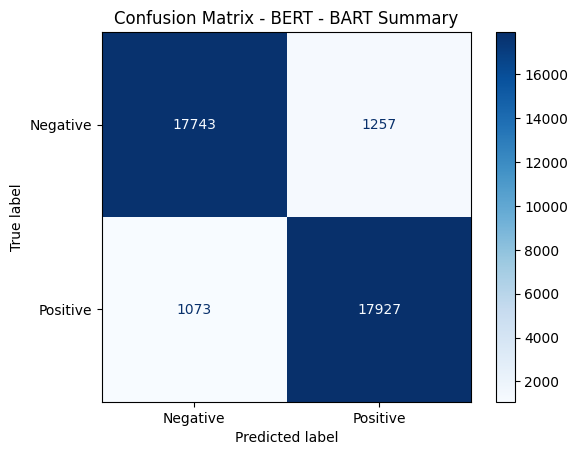

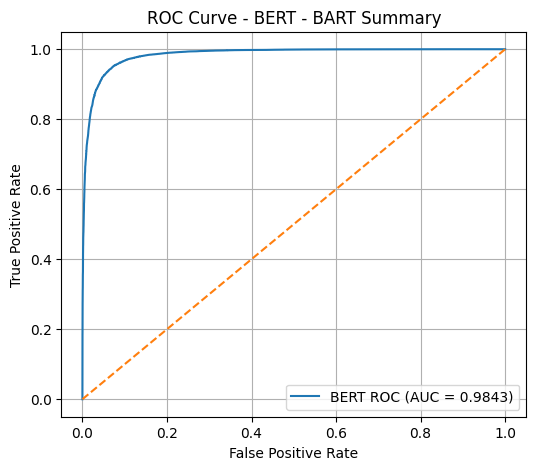

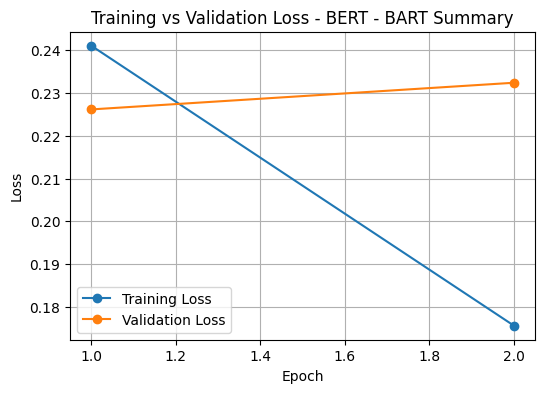

Saved partial result: /content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_results_partial.csv

FINAL BERT BART CLASSIFICATION RESULT


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Batch Size,Epochs,Max Length,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (min),Inference Time (sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,BART,Single Abstractive Summary,BERT,bert-base-uncased,8,2,256,0.9387,0.9345,0.9435,0.939,0.9843,108.16,77.12,2143.97,1508.38,NVIDIA A100-SXM4-40GB



Saved final result: /content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_results_final.csv


In [ ]:
# =====================================================
# CELL 10: RUN BERT WITH RESUME SUPPORT
# =====================================================
partial_df = load_partial_results()

if is_completed(partial_df):
    print("BERT | BART | Single Abstractive Summary already completed.")
    results_df = partial_df
else:
    bert_result = run_experiment()
    append_partial_result(bert_result)

    results_df = pd.read_csv(PARTIAL_RESULTS_PATH)

print("\nFINAL BERT BART CLASSIFICATION RESULT")
display(results_df)

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
print(f"\nSaved final result: {FINAL_RESULTS_PATH}")

In [ ]:
# =====================================================
# CELL 11: VIEW SAVED FILES
# =====================================================
print("Output folder:")
print(RUN_OUTPUT_DIR)

print("\nFiles generated:")
for root, dirs, files in os.walk(RUN_OUTPUT_DIR):
    for file in files:
        print(os.path.join(root, file))

Output folder:
/content/drive/MyDrive/yelp_bart_classification_outputs

Files generated:
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_results_partial.csv
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_results_final.csv
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/bert_confusion_matrix.png
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/bert_roc_curve.png
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/bert_train_val_loss.png
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/bert_metrics.csv
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/checkpoint-126000/config.json
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/checkpoint-126000/model.safetensors
/content/drive/MyDrive/yelp_bart_classification_outputs/bert_bart_single_summary/checkpoint-126000/toke

In [ ]:
# =====================================================
# YELP BART SUMMARY CLASSIFICATION
# XLNET ONLY
# SAME PARAMS AS BERT FOR FAIR COMPARISON
# INPUT = Yelp BART summarised dataset
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# =====================================================
# SEED
# =====================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# =====================================================
# PATHS
# =====================================================
BASE_DIR = "/content/drive/MyDrive/yelp_bart_abstractive_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_bart_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f"{BASE_DIR}/yelp_bart_abstractive_train_for_classification.csv"
VAL_PATH   = f"{BASE_DIR}/yelp_bart_abstractive_val_for_classification.csv"
TEST_PATH  = f"{BASE_DIR}/yelp_bart_abstractive_test_for_classification.csv"

MODEL_LABEL = "XLNet"
MODEL_NAME = "xlnet-base-cased"

PARTIAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_bart_results_partial.csv")
FINAL_RESULTS_PATH   = os.path.join(RUN_OUTPUT_DIR, "xlnet_bart_results_final.csv")

# =====================================================
# SAME PARAMS AS BERT
# =====================================================
MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1

# =====================================================
# HELPERS
# =====================================================
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:,1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# =====================================================
# LOAD DATA
# =====================================================
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

train_texts = train_df["text"].fillna("").astype(str).apply(clean_text).tolist()
val_texts   = val_df["text"].fillna("").astype(str).apply(clean_text).tolist()
test_texts  = test_df["text"].fillna("").astype(str).apply(clean_text).tolist()

train_labels = train_df["label"].astype(int).tolist()
val_labels   = val_df["label"].astype(int).tolist()
test_labels  = test_df["label"].astype(int).tolist()

print("Train:", len(train_texts))
print("Val  :", len(val_texts))
print("Test :", len(test_texts))

# =====================================================
# TOKENIZER
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else tokenizer.unk_token

train_enc = tokenizer(train_texts, truncation=True, padding=False, max_length=MAX_LENGTH)
val_enc   = tokenizer(val_texts, truncation=True, padding=False, max_length=MAX_LENGTH)
test_enc  = tokenizer(test_texts, truncation=True, padding=False, max_length=MAX_LENGTH)

train_dataset = TextDataset(train_enc, train_labels)
val_dataset   = TextDataset(val_enc, val_labels)
test_dataset  = TextDataset(test_enc, test_labels)

# =====================================================
# MODEL
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

if model.config.pad_token_id is None:
    model.config.pad_token_id = tokenizer.pad_token_id

# =====================================================
# TRAINER
# =====================================================
args = TrainingArguments(
    output_dir=os.path.join(RUN_OUTPUT_DIR, "xlnet_bart_single_summary"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    optim="adamw_torch"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
)

# =====================================================
# TRAIN
# =====================================================
start = time.time()
trainer.train()
train_time = time.time() - start

# =====================================================
# TEST
# =====================================================
pred = trainer.predict(test_dataset)

y_true = np.array(test_labels)
y_pred = np.argmax(pred.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:,1].numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc_value = roc_auc_score(y_true, y_prob)

# =====================================================
# RESULTS
# =====================================================
print("\n=== FINAL XLNET RESULTS ===")
print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1       :", round(f1,4))
print("ROC-AUC  :", round(roc_auc_value,4))
print("Training Time (min):", round(train_time/60,2))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Negative","Positive"]))

# =====================================================
# SAVE
# =====================================================
results_df = pd.DataFrame([{
    "Model":"XLNet",
    "Summary Method":"BART",
    "Summary Length":"Single Abstractive Summary",
    "Accuracy":round(acc,4),
    "Precision":round(prec,4),
    "Recall":round(rec,4),
    "F1":round(f1,4),
    "ROC-AUC":round(roc_auc_value,4),
    "Training Time (min)":round(train_time/60,2),
    "Batch Size":BATCH_SIZE,
    "Epochs":EPOCHS,
    "Learning Rate":LEARNING_RATE
}])

results_df.to_csv(FINAL_RESULTS_PATH, index=False)
print("\nSaved:", FINAL_RESULTS_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Train: 503994
Val  : 56000
Test : 38000


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.256059,0.213362,0.935750,0.929371,0.943179,0.936224,0.982932
2,0.191758,0.224191,0.940054,0.936484,0.944143,0.940298,0.984860


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== FINAL XLNET RESULTS ===
Accuracy : 0.9399
Precision: 0.9365
Recall   : 0.9438
F1       : 0.9401
ROC-AUC  : 0.9848
Training Time (min): 165.38

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94     19000
    Positive       0.94      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000


Saved: /content/drive/MyDrive/yelp_bart_classification_outputs/xlnet_bart_results_final.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_bart_classification_outputs"

for root, dirs, files in os.walk(RUN_OUTPUT_DIR):
    for f in files:
        if "xlnet" in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/yelp_bart_classification_outputs/xlnet_bart_results_final.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Train: True /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_train_for_classification.csv
Val  : True /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_val_for_classification.csv
Test : True /content/drive/MyDrive/yelp_bart_abstractive_outputs/yelp_bart_abstractive_test_for_classification.csv
Train: 503994
Val  : 56000
Test : 38000


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 46.41
Train avg tokens after trunc : 46.41
Train truncation %          : 0.0
Test avg tokens before trunc: 46.3
Test avg tokens after trunc : 46.3
Test truncation %           : 0.0


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.256059,0.213362,0.935750,0.929371,0.943179,0.936224,0.982932
2,0.191758,0.224191,0.940054,0.936484,0.944143,0.940298,0.984860


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== FINAL XLNET RESULTS ===
Accuracy : 0.9399
Precision: 0.9365
Recall   : 0.9438
F1       : 0.9401
ROC-AUC  : 0.9848
Training time: 159 min 36.32 sec
Inference time: 1 min 53.79 sec
Inference latency per sample (ms): 2.9944
Training throughput: 52.63 samples/sec
Inference throughput: 333.95 samples/sec

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94     19000
    Positive       0.94      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000



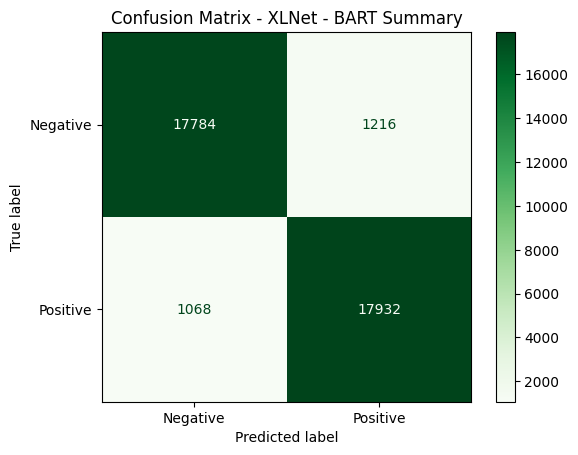

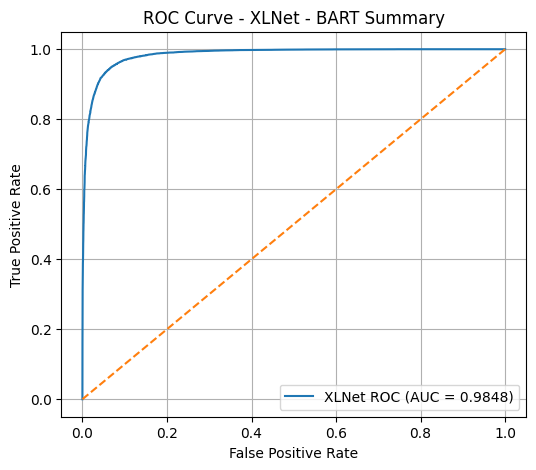

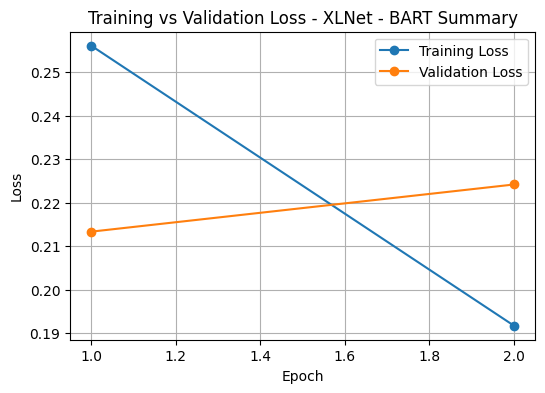


Saved final result:
/content/drive/MyDrive/yelp_bart_classification_outputs/xlnet_bart_results_final_v2.csv

Saved full artifacts to:
/content/drive/MyDrive/yelp_bart_classification_outputs/xlnet_bart_single_summary_full_outputs


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,BART,Single Abstractive Summary,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.0,159.61,79.8,113.79,2.9944,52.63,333.95,2419.38,1640.69,NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# FINAL XLNET CODE
# YELP BART SUMMARY CLASSIFICATION
# FULL THESIS-READY OUTPUTS
# RERUN VERSION
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback, set_seed
)

from google.colab import drive
drive.mount("/content/drive")

warnings.filterwarnings("ignore")

# =====================================================
# CONFIG
# =====================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

BASE_DIR = "/content/drive/MyDrive/yelp_bart_abstractive_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_bart_classification_outputs"
OUTPUT_DIR = os.path.join(RUN_OUTPUT_DIR, "xlnet_bart_single_summary_full_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f"{BASE_DIR}/yelp_bart_abstractive_train_for_classification.csv"
VAL_PATH = f"{BASE_DIR}/yelp_bart_abstractive_val_for_classification.csv"
TEST_PATH = f"{BASE_DIR}/yelp_bart_abstractive_test_for_classification.csv"

MODEL_LABEL = "XLNet"
MODEL_NAME = "xlnet-base-cased"

MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_bart_results_final_v2.csv")

print("Train:", os.path.exists(TRAIN_PATH), TRAIN_PATH)
print("Val  :", os.path.exists(VAL_PATH), VAL_PATH)
print("Test :", os.path.exists(TEST_PATH), TEST_PATH)

# =====================================================
# DATASET + HELPERS
# =====================================================
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None


def format_seconds(seconds):
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"


@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float


def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }


def plot_confusion_matrix_save(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap="Greens")
    plt.title("Confusion Matrix - XLNet - BART Summary")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm


def plot_roc_curve_save(y_true, y_prob, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"XLNet ROC (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - XLNet - BART Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_train_val_loss_save(trainer, save_path):
    history = trainer.state.log_history

    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])

        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss - XLNet - BART Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


# =====================================================
# LOAD DATA
# =====================================================
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"{name} file must contain columns: text, label")

train_texts = train_df["text"].fillna("").astype(str).apply(clean_text).tolist()
val_texts = val_df["text"].fillna("").astype(str).apply(clean_text).tolist()
test_texts = test_df["text"].fillna("").astype(str).apply(clean_text).tolist()

train_labels = train_df["label"].astype(int).tolist()
val_labels = val_df["label"].astype(int).tolist()
test_labels = test_df["label"].astype(int).tolist()

print("Train:", len(train_texts))
print("Val  :", len(val_texts))
print("Test :", len(test_texts))

# =====================================================
# TOKENIZE
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=MAX_LENGTH)
val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=MAX_LENGTH)
test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=MAX_LENGTH)

print("\n=== TOKEN / TRUNCATION STATS ===")
print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
print("Train avg tokens after trunc :", round(train_stats.avg_tokens_after, 2))
print("Train truncation %          :", round(train_stats.truncation_pct, 2))
print("Test avg tokens before trunc:", round(test_stats.avg_tokens_before, 2))
print("Test avg tokens after trunc :", round(test_stats.avg_tokens_after, 2))
print("Test truncation %           :", round(test_stats.truncation_pct, 2))

train_dataset = TextDataset(train_enc, train_labels)
val_dataset = TextDataset(val_enc, val_labels)
test_dataset = TextDataset(test_enc, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =====================================================
# MODEL + TRAINER
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

if model.config.pad_token_id is None:
    model.config.pad_token_id = tokenizer.pad_token_id

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    optim="adamw_torch"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
)

# =====================================================
# TRAIN
# =====================================================
reset_gpu_memory()
train_start = time.time()
trainer.train()
train_time = time.time() - train_start
peak_train_mem = get_peak_gpu_memory_mb()

# =====================================================
# TEST / INFERENCE
# =====================================================
reset_gpu_memory()
infer_start = time.time()
pred = trainer.predict(test_dataset)
infer_time = time.time() - infer_start
peak_infer_mem = get_peak_gpu_memory_mb()

y_true = np.array(test_labels)
y_pred = np.argmax(pred.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc_value = roc_auc_score(y_true, y_prob)

num_train = len(train_dataset)
num_val = len(val_dataset)
num_test = len(test_dataset)

train_time_per_epoch = train_time / EPOCHS
train_samples_per_sec = num_train / train_time
infer_samples_per_sec = num_test / infer_time
infer_latency_per_sample_ms = (infer_time / num_test) * 1000

print("\n=== FINAL XLNET RESULTS ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1       :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc_value, 4))
print("Training time:", format_seconds(train_time))
print("Inference time:", format_seconds(infer_time))
print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
print("Training throughput:", round(train_samples_per_sec, 2), "samples/sec")
print("Inference throughput:", round(infer_samples_per_sec, 2), "samples/sec")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

# =====================================================
# SAVE ARTIFACTS
# =====================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0,
    output_dict=True
)

cm = plot_confusion_matrix_save(
    y_true,
    y_pred,
    os.path.join(OUTPUT_DIR, "xlnet_bart_confusion_matrix.png")
)

pd.DataFrame(
    cm,
    index=["Actual_Negative", "Actual_Positive"],
    columns=["Pred_Negative", "Pred_Positive"]
).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_bart_confusion_matrix_values.csv")
)

plot_roc_curve_save(
    y_true,
    y_prob,
    os.path.join(OUTPUT_DIR, "xlnet_bart_roc_curve.png")
)

plot_train_val_loss_save(
    trainer,
    os.path.join(OUTPUT_DIR, "xlnet_bart_train_val_loss.png")
)

pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_bart_classification_report.csv")
)

pd.DataFrame(trainer.state.log_history).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_bart_training_log_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_positive": y_prob
}).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_bart_test_predictions.csv"),
    index=False
)

result = {
    "Input Type": "Summarised Text",
    "Summary Method": "BART",
    "Summary Length": "Single Abstractive Summary",
    "Model": MODEL_LABEL,
    "Checkpoint": MODEL_NAME,
    "Optimizer": OPTIMIZER_NAME,
    "Max Length": MAX_LENGTH,
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning Rate": LEARNING_RATE,
    "Weight Decay": WEIGHT_DECAY,

    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC-AUC": round(roc_auc_value, 4),

    "Train Samples": num_train,
    "Validation Samples": num_val,
    "Test Samples": num_test,

    "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
    "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
    "Max Train Tokens Before Trunc": train_stats.max_tokens_before,
    "Train Truncated Count": train_stats.truncated_count,
    "Train Truncation %": round(train_stats.truncation_pct, 2),

    "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
    "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
    "Max Test Tokens Before Trunc": test_stats.max_tokens_before,
    "Test Truncated Count": test_stats.truncated_count,
    "Test Truncation %": round(test_stats.truncation_pct, 2),

    "Training Time (min)": round(train_time / 60, 2),
    "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
    "Inference Time (sec)": round(infer_time, 2),
    "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
    "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
    "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
    "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
    "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
    "Device": device_name
}

results_df = pd.DataFrame([result])
results_df.to_csv(FINAL_RESULTS_PATH, index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "xlnet_bart_metrics.csv"), index=False)

print("\nSaved final result:")
print(FINAL_RESULTS_PATH)

print("\nSaved full artifacts to:")
print(OUTPUT_DIR)

display(results_df)